# a02 Example - Gaussian Process Bayesian Optimization Using `GPBayesianOptimizeScan` implementation of `AbstractOptimizeScan`

# Install External Libraries for Optimizer Implementation

In [ ]:
!python -m pip install torch gpytorch

# Imports

In [1]:
import pyscan as ps
import numpy as np
import matplotlib.pyplot as plt

## Setup devices

In [2]:
devices = ps.ItemAttribute()

devices.v1 = ps.TestVoltage() # Device 1
devices.v2 = ps.TestVoltage() # Device 2

## Define a measure function

In [3]:
def voltage_response(v1, v2):
    """
    Paraboloid function to optimize.
    """
    return (v1 - 4)**2 + (v2 - 6)**2

def get_voltage_data(expt):
    """
    Reads the voltage from v1 and v2. Also adds a calculated voltage response to optimize.
    """

    runinfo = expt.runinfo
    devices = expt.devices

    d = ps.ItemAttribute()

    d.v1_readout = devices.v1.voltage
    d.v2_readout = devices.v2.voltage

    d.vf = voltage_response(d.v1_readout, d.v2_readout)

    return d

# Define live plot

In [4]:
@ps.live_plot
def plot_optim_live(expt):
    global fig, ax, cb0, cb1
    x, y = np.mgrid[0:10:.01, 0:10:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
                cmap='viridis')
    ax.set_box_aspect(1)
    if cb0 is None and cb1 is None:
        cb0 = fig.colorbar(scatter, label="optimizer step")
        cb1 = fig.colorbar(pcm, label="voltage response")
    else:
        cb0.update_normal(scatter)
    ax.legend(["optimizer decision process",], loc='lower left', bbox_to_anchor=(.1, -.3))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_title("Optimization of Voltage Response")

# Define runinfo

In [5]:
runinfo = ps.RunInfo()
runinfo.measure_function = get_voltage_data

# Implement `AbstractOptimizeScan` with `GPBayesianOptimizeScan`

# Instantiate OptimizeScan

In [6]:
runinfo.scan0 = ps.GPBayesianOptimizeScan(('v1', 'v2'), ('voltage', 'voltage'), (1., 1.), ('v1_readout', 'v2_readout'),
                                          'vf',
                                          [(0, 10, .1), (0, 10, .1)],
                                          dt=1., n_max=100,
                                          initialization_scans=[[9., 1.], [9., 9.], [1., 9.]],
                                          extremum='min', ei_threshold=1e-2)

# Run Experiments

In [ ]:
expt = ps.Experiment(runinfo, devices)
expt.start_thread()

PyTorch version: 2.8.0+cpu
Computation successful on: cpu
PyTorch version: 2.8.0+cpu
Computation successful on: cpu
PyTorch version: 2.8.0+cpu
Computation successful on: cpu
PyTorch version: 2.8.0+cpu
Computation successful on: cpu
PyTorch version: 2.8.0+cpu
Computation successful on: cpu
PyTorch version: 2.8.0+cpu
Computation successful on: cpu
PyTorch version: 2.8.0+cpu
Computation successful on: cpu
PyTorch version: 2.8.0+cpu
Computation successful on: cpu
PyTorch version: 2.8.0+cpu
Computation successful on: cpu
Stopping Experiment


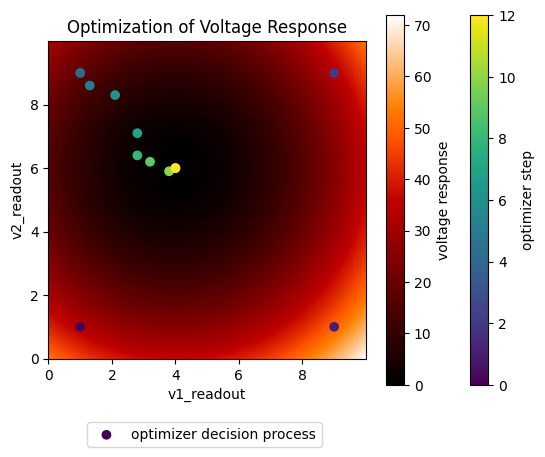

In [8]:
fig, ax = plt.subplots()
cb0 = cb1 = None
try:
    plot_optim_live(expt)
except KeyboardInterrupt:
    expt.stop()

In [9]:
expt.__dict__

{'runinfo': <pyscan.measurement.run_info.RunInfo at 0x2395412da60>,
 'devices': <itemattribute.item_attribute.ItemAttribute at 0x23953dbf170>,
 'expt_thread': <Thread(Thread-3 (run), stopped daemon 19400)>,
 'iteration': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13.]),
 'v1_readout': array([1.        , 9.        , 9.        , 1.        , 1.        ,
        1.29999995, 2.0999999 , 2.80000019, 2.80000019, 3.20000005,
        3.79999995, 4.        , 4.        , 4.        ]),
 'v2_readout': array([1.        , 1.        , 9.        , 9.        , 9.        ,
        8.60000038, 8.30000019, 7.0999999 , 6.4000001 , 6.19999981,
        5.9000001 , 6.        , 6.        , 6.        ]),
 'vf': array([34.        , 50.        , 34.        , 18.        , 18.        ,
        14.05000224,  8.90000124,  2.64999933,  1.59999962,  0.67999985,
         0.05      ,  0.        ,  0.        ,  0.        ])}

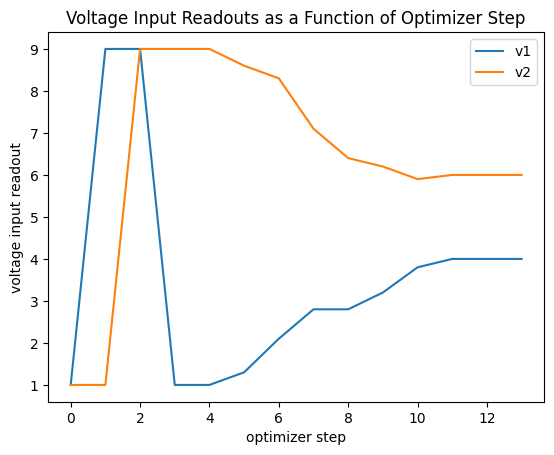

In [10]:
plt.plot(list(zip(expt.v1_readout, expt.v2_readout)))
plt.legend(['v1', 'v2'])
plt.xlabel("optimizer step")
plt.ylabel("voltage input readout")
plt.title("Voltage Input Readouts as a Function of Optimizer Step");

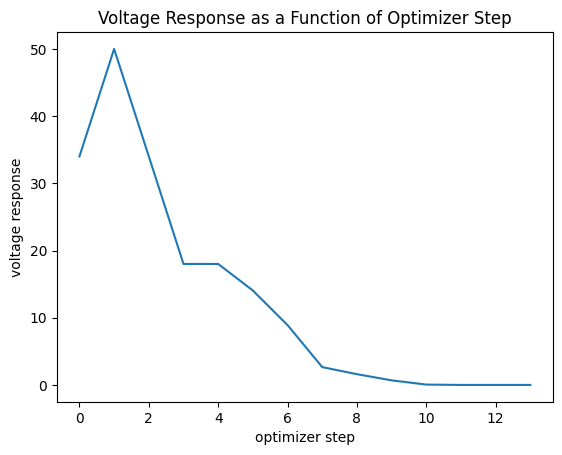

In [11]:
plt.plot(expt.vf)
plt.xlabel("optimizer step")
plt.ylabel("voltage response")
plt.title("Voltage Response as a Function of Optimizer Step");

In [12]:
def plot_optim_pcm():
    fig, ax = plt.subplots()
    x, y = np.mgrid[0:10:.01, 0:10:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
                         cmap='viridis')
    ax.set_box_aspect(1)
    fig.colorbar(scatter, label="optimizer step")
    fig.colorbar(pcm, label="voltage response")
    ax.legend(["optimizer decision process",], loc='lower left', bbox_to_anchor=(.1, -.3))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_title("Optimization of Voltage Response")

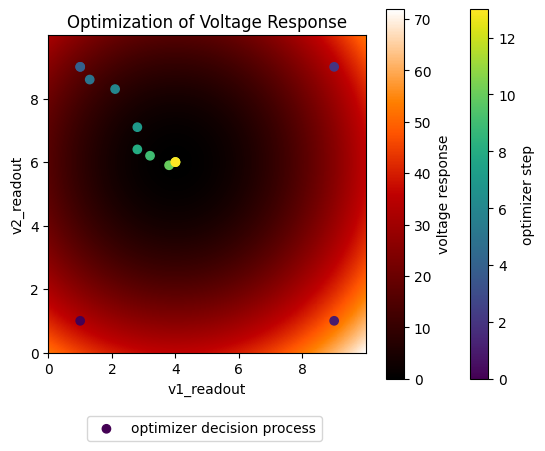

In [13]:
plot_optim_pcm()

In [14]:
def plot_optim_3d(elevation, azimuth):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    x, y = np.mgrid[0:10:.01, 0:10:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    ax.plot_surface(x, y, z, color='C1', alpha=.5)
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, expt.vf, c=range(len(expt.v1_readout)))
    ax.view_init(elev=elevation, azim=azimuth)
    fig.colorbar(scatter, label="optimizer step", pad=.1)
    ax.legend(["voltage response function", "optimizer decision process",], loc='lower left', bbox_to_anchor=(.2, -.2))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_zlabel("voltage response")
    ax.set_title("Optimization of Voltage Response")

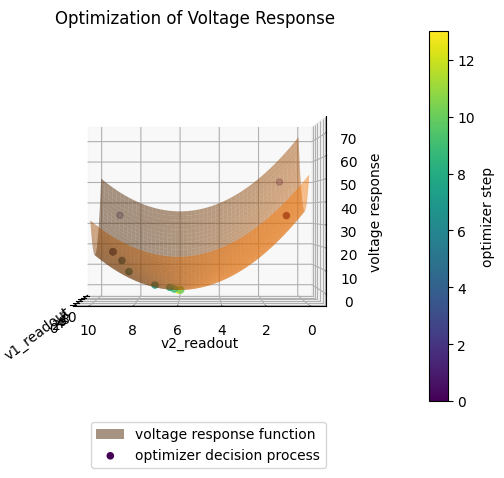

In [15]:
plot_optim_3d(0, 180)

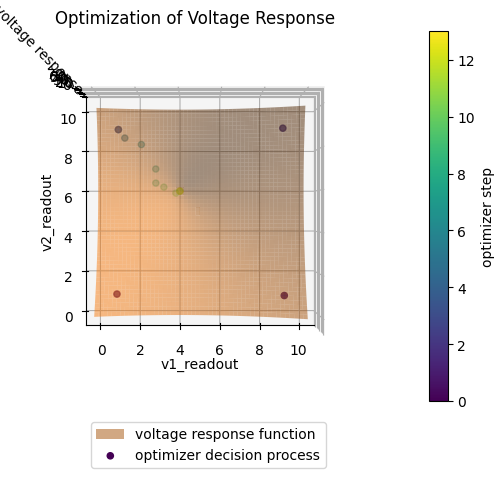

In [16]:
plot_optim_3d(90, 270)

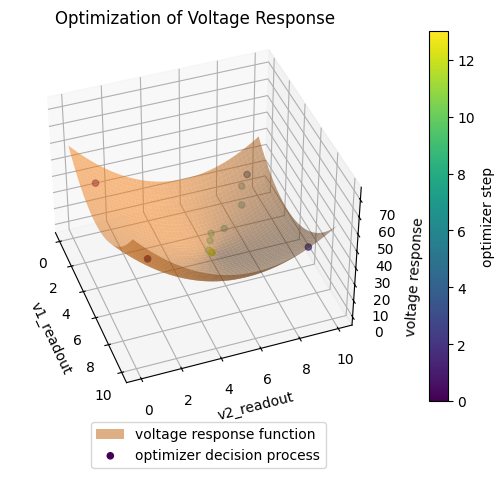

In [17]:
plot_optim_3d(40,-20)